# otwin 03 · Scoring a forecast so it cannot flatter you

**Question.** A battery has been cycled 100 times. A model fitted to those cycles forecasts the
next 68. How good is that forecast — *honestly*?

**What otwin does here.** Everything on the scoring side: the metrics, the reference forecasters
you must beat, the interval diagnostics, and an `evaluate` function whose interface makes it
impossible to hand the model the answers.

**What you write yourself.** The model. otwin has no fade laws and no regressors, on purpose —
capacity fade has no energy function and no port, so it does not belong in the physics modules.
You bring a model; otwin tells you whether it is any good.

**What you will learn**

1. how to score a forecast with `otwin.forecast` metrics, and why `theil_u` builds its own benchmark
2. why "beats persistence" is not enough, and what `get_best_baseline` does about it
3. how to tell a fitted parameter from an artefact of where you stopped fitting
4. how `evaluate` refuses to let a model see the test data

*Data: NASA PCoE, four lithium-ion cells, real measurements. Runtime ≈ 3 min. Opens in Colab.*


## Setup

Three cells you can skip on first reading: install, plotting style, and the data file. The data cell will ask you to upload `discharge.csv` in Colab; the route it used is printed.

In [1]:
# otwin from PyPI. This is the whole point of the notebook: no clone, no path
# surgery, no vendored copy of the model code.
!pip install -q otwin 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])


otwin 0.3.1 | python 3.13.15


In [2]:
# Inlined plotting style. Self-contained on purpose: nothing here imports
# from another file in this repository.
import os, json
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from otwin.forecast import (rmse, mae, nrmse, mase, theil_u, skill_score,
                             persistence, drift, mean_forecast, get_best_baseline,
                             picp, mpiw, interval_score)
from otwin.forecast import evaluate, ForecastInterfaceError
import matplotlib; import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
BAND_ALPHA = 0.18
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p


In [3]:
# The NASA PCoE discharge CSV is the only external input. Resolution order,
# with the chosen route printed:
#   (a) a download URL, if you set CANDIDATE_URL
#   (b) google.colab.files.upload()  - the normal Colab route
#   (c) a local file, for offline / CI runs

CANDIDATE_URL = ""
LOCAL_CANDIDATES = ["discharge.csv", "data/discharge.csv", "/content/discharge.csv"]
EXPECTED_ROWS = 169766
EXPECTED_CELLS = ["B0005", "B0006", "B0007", "B0018"]

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

DATA, route = None, None
if CANDIDATE_URL:
    try:
        import urllib.request
        urllib.request.urlretrieve(CANDIDATE_URL, "discharge.csv")
        DATA, route = "discharge.csv", "(a) downloaded from CANDIDATE_URL"
    except Exception as e:
        print("URL download failed:", e)
if DATA is None:
    for p in LOCAL_CANDIDATES:
        if os.path.exists(p):
            DATA, route = p, f"(c) local file: {p}"; break
if DATA is None and _in_colab():
    from google.colab import files
    up = files.upload(); DATA = list(up.keys())[0]; route = f"(b) uploaded in Colab: {DATA}"
if DATA is None:
    raise FileNotFoundError("No data source. Set CANDIDATE_URL, upload the CSV in Colab, "
                            "or put discharge.csv next to this notebook.")
print("DATA route:", route); print("DATA path :", DATA)

raw = pd.read_csv(DATA)
assert sorted(raw.Battery.unique().tolist()) == EXPECTED_CELLS, "unexpected battery IDs"
assert len(raw) == EXPECTED_ROWS, f"expected {EXPECTED_ROWS} rows, found {len(raw)}"
print("rows:", len(raw), "| cells:", sorted(raw.Battery.unique().tolist()))
print("Sanity checks passed.")


DATA route: (c) local file: discharge.csv
DATA path : discharge.csv
rows: 169766 | cells: ['B0005', 'B0006', 'B0007', 'B0018']
Sanity checks passed.


## 1 · The data: one row per discharge cycle

The raw file has a voltage and current sample every few seconds. We reduce it to one row per
cycle: capacity, throughput, energy, temperature. **State of health** is capacity divided by
capacity at cycle 1.

*Look at:* the cycle at which each cell first drops below 0.80 SoH — the retirement threshold.
Cell B0006 gets there at cycle 61, B0007 not until 124. Same chemistry, same test, twice the
life. That spread is what a forecast has to cope with.

In [4]:
AMBIENT = 24.0
CELLS = ["B0005", "B0006", "B0007", "B0018"]

def cycle_table(raw, battery):
    d = raw[raw.Battery == battery].sort_values(["id_cycle", "Time"]); rows = []
    for c, g in d.groupby("id_cycle"):
        t = g.Time.to_numpy(float); v = g.Voltage_measured.to_numpy(float)
        i = np.abs(g.Current_measured.to_numpy(float)); T = g.Temperature_measured.to_numpy(float)
        rows.append(dict(cycle=int(c), capacity_Ah=float(g.Capacity.iloc[0]),
                         throughput_Ah=float(np.trapezoid(i, t)/3600.0),
                         energy_Wh=float(np.trapezoid(i*v, t)/3600.0),
                         T_mean_C=float(T.mean()), T_max_C=float(T.max())))
    f = pd.DataFrame(rows).sort_values("cycle").reset_index(drop=True)
    f["SoH"] = f.capacity_Ah/f.capacity_Ah.iloc[0]
    f["cum_throughput_Ah"] = f.throughput_Ah.cumsum()
    return f

tabs = {b: cycle_table(raw, b) for b in CELLS}
f = tabs["B0005"]
cyc = f.cycle.to_numpy(float); soh = f.SoH.to_numpy(float)
cum = f.cum_throughput_Ah.to_numpy(float); thr = f.throughput_Ah.to_numpy(float)
cap1 = float(f.capacity_Ah.iloc[0])

for b in CELLS:
    t_ = tabs[b]; n80 = t_.cycle[t_.SoH < 0.80]
    print("%s: %3d cycles | cap %.4f -> %.4f Ah | SoH final %.4f | first SoH<0.80 at cycle %s"
          % (b, len(t_), t_.capacity_Ah.iloc[0], t_.capacity_Ah.iloc[-1], t_.SoH.iloc[-1],
             int(n80.iloc[0]) if len(n80) else "never"))
print("\nB0005 cumulative throughput: %.4f Ah" % f.cum_throughput_Ah.iloc[-1])

B0005: 168 cycles | cap 1.8565 -> 1.3251 Ah | SoH final 0.7138 | first SoH<0.80 at cycle 101
B0006: 168 cycles | cap 2.0353 -> 1.1857 Ah | SoH final 0.5825 | first SoH<0.80 at cycle 61
B0007: 168 cycles | cap 1.8911 -> 1.4325 Ah | SoH final 0.7575 | first SoH<0.80 at cycle 124
B0018: 132 cycles | cap 1.8550 -> 1.3411 Ah | SoH final 0.7229 | first SoH<0.80 at cycle 75

B0005 cumulative throughput: 263.6264 Ah


## 2 · The model you bring

This cell is **your code, not otwin's**. It is the model from the original study: a fade law
in cumulative charge throughput $Q$, `SoH = 1 − c·Q^z`, plus a Gaussian process on the
training residual. Four variants of the law are defined so we can compare them later.

Two things to notice, because they are the difference between a forecast and a fit:

- the model is rolled **closed loop** — future throughput is rebuilt from *predicted* capacity,
  so nothing measured after the split enters the forecast;
- the residual GP is trained on the training window only.

You do not need to understand every line. You need to know it returns four forecasts:
`phys` (the law alone), `hybrid` (law + GP), `data_gp` (GP alone, no physics) and `pers`
(persistence: "SoH stays where it is").

In [5]:
VARIANTS = {
    "a_free_z":    dict(label="c·Q^z, z free",        kind="thr", p0=[1e-3, 1.0], f=lambda Q, c, z: 1-c*Q**z),
    "b_z_1":       dict(label="c·Q  (z = 1)",         kind="thr", p0=[1e-3],      f=lambda Q, c: 1-c*Q),
    "c_z_0p5":     dict(label="c·√Q (z = 0.5)",       kind="thr", p0=[1e-2],      f=lambda Q, c: 1-c*np.sqrt(Q)),
    "d_lin_cycle": dict(label="c·n (linear in cycle)",kind="cyc", p0=[1e-3],      f=lambda n, c: 1-c*n),
}

def fit_all(variant, cyc, soh, cum, cap1, split, n_ahead=None, restarts=6):
    V = VARIANTS[variant]; m = cyc <= split
    n_ahead = int((cyc > split).sum()) if n_ahead is None else n_ahead
    k_thr = float(np.mean((cum[m]-np.concatenate([[0.0], cum[m][:-1]]))/(soh[m]*cap1)))
    x = cum[m] if V["kind"] == "thr" else cyc[m]
    p, C = curve_fit(V["f"], x, soh[m], p0=V["p0"], maxfev=300000)
    ph_in = V["f"](x, *p)
    if V["kind"] == "cyc":
        ph_out = V["f"](cyc[m][-1] + np.arange(1, n_ahead+1), *p)
    else:
        out, Q, s = [], cum[m][-1], soh[m][-1]
        for _ in range(n_ahead):
            Q += k_thr*s*cap1; s = V["f"](Q, *p); out.append(s)
        ph_out = np.array(out)
    X = cyc.reshape(-1, 1); mu, sd = X[m].mean(), X[m].std()
    Xf = (np.arange(1, n_ahead+1) + cyc[m][-1]).reshape(-1, 1)
    r = soh[m] - ph_in
    kr = ConstantKernel(np.var(r)+1e-10, (1e-10, 1e2))*Matern(1.0, (1e-2, 1e3), nu=2.5) + WhiteKernel(1e-6, (1e-12, 1e-1))
    gr = GaussianProcessRegressor(kernel=kr, alpha=0.0, normalize_y=False,
                                  n_restarts_optimizer=restarts, random_state=0).fit((X[m]-mu)/sd, r)
    kd = ConstantKernel(np.var(soh[m]), (1e-10, 1e2))*Matern(1.0, (1e-2, 1e3), nu=2.5) + WhiteKernel(1e-6, (1e-12, 1e-1))
    gd = GaussianProcessRegressor(kernel=kd, alpha=0.0, normalize_y=True,
                                  n_restarts_optimizer=restarts, random_state=0).fit((X[m]-mu)/sd, soh[m])
    return dict(p=p, se=np.sqrt(np.diag(np.atleast_2d(C))),
                phys=ph_out, hybrid=ph_out + gr.predict((Xf-mu)/sd),
                data_gp=gd.predict((Xf-mu)/sd), pers=np.full(n_ahead, soh[m][-1]))
print("variants:", list(VARIANTS))

variants: ['a_free_z', 'b_z_1', 'c_z_0p5', 'd_lin_cycle']


## 3 · Score it with otwin

Train on cycles 1–100, forecast 101–168, and score every forecast with `otwin.forecast`.

The one call to understand is `theil_u(y_true, y_pred, y_train)`. It takes the *training*
series and builds the persistence benchmark itself. You never pass a reference forecast in —
so you cannot choose a flattering one after seeing the result.

*Look at:* the Theil's U column. Below 1 means the model beats "hold SoH constant". The hybrid
scores **1.0007**. It is exactly as good as doing nothing.

In [6]:
SPLIT = 100
M100 = fit_all("a_free_z", cyc, soh, cum, cap1, SPLIT)
obs = soh[cyc > SPLIT]; train = soh[cyc <= SPLIT]
c_hat, z_hat = M100["p"]

print("fitted fade law: SoH = 1 - %.6e * Q^%.6f" % (c_hat, z_hat))
print()
print("%-16s %10s %10s %10s %10s" % ("model", "RMSE", "MAE", "Theil U", "skill"))
for name, pred in [("hybrid", M100["hybrid"]), ("physics only", M100["phys"]),
                   ("data-only GP", M100["data_gp"]), ("persistence", M100["pers"])]:
    print("%-16s %10.4f %10.4f %10.4f %10.4f"
          % (name, rmse(obs, pred), mae(obs, pred), theil_u(obs, pred, train),
             skill_score(rmse(obs, pred), rmse(obs, M100["pers"]))))
print("\notwin.forecast.persistence reproduces the notebook's benchmark exactly:",
      bool(np.allclose(persistence(train, len(obs)), M100["pers"])))


fitted fade law: SoH = 1 - 2.134759e-05 * Q^1.785084

model                  RMSE        MAE    Theil U      skill
hybrid               0.0678     0.0581     1.0007    -0.0007
physics only         0.0678     0.0582     1.0011    -0.0011
data-only GP         0.1619     0.1462     2.3899    -1.3899
persistence          0.0677     0.0603     1.0000     0.0000

otwin.forecast.persistence reproduces the notebook's benchmark exactly: True


Why? The GP reverts to zero within a few cycles of the split, so beyond that the hybrid *is*
the fade law — and the fade law with a free exponent is the problem. Section 5 shows why.

## 4 · A harder opponent

Persistence is the weakest reference there is. On a series that is steadily falling, "keep
falling at the recent rate" (drift) is far harder to beat. `get_best_baseline` fits
persistence, drift, mean and seasonal-naive and returns whichever is **hardest**. That choice
is made by the library, not by you.

*Look at:* skill against drift. The same forecast that tied with persistence is **70 % worse**
than drift. The original study reported the first number. Both are true; only the second one
tells you whether the model is useful.

In [7]:
bn, bp, berr = get_best_baseline(train, obs)
print("hardest baseline on B0005 at split 100: %-12s RMSE %.4f" % (bn, berr))
print("persistence                            RMSE %.4f" % rmse(obs, persistence(train, len(obs))))
print("drift                                  RMSE %.4f" % rmse(obs, drift(train, len(obs))))
print("mean                                   RMSE %.4f" % rmse(obs, mean_forecast(train, len(obs))))
print()
print("hybrid RMSE %.4f -> skill vs the hardest baseline: %+.3f"
      % (rmse(obs, M100["hybrid"]), skill_score(rmse(obs, M100["hybrid"]), berr)))

hardest baseline on B0005 at split 100: drift        RMSE 0.0400
persistence                            RMSE 0.0677
drift                                  RMSE 0.0400
mean                                   RMSE 0.1821

hybrid RMSE 0.0678 -> skill vs the hardest baseline: -0.696


## 5 · Is the fitted exponent real?

The law fitted $z = 1.79$. A physically meaningful exponent should not depend on where you stop
fitting. So: refit at four different split points and watch it.

*Look at:* the `a_free_z` row. Theil's U swings from 0.64 to 1.27 depending on the split, and
the exponent with it. That is not a parameter the data determined; it is a parameter the noise
chose. Compare the `b_z_1` row, exponent pinned to 1: stable, and better at every split.

(otwin 0.4.0 has a check for exactly this — `otwin.estimate.identifiability`. Notebook 07 uses it.
Here we see the symptom by hand first.)

Set `QUICK = False` for all eight splits; it takes about a minute longer.

In [8]:
QUICK  = True
SPLITS = [70, 85, 100, 120] if QUICK else [60, 70, 80, 85, 90, 100, 110, 120]
REST   = 3 if QUICK else 6

rows = []
for s in SPLITS:
    ob = soh[cyc > s]; tr = soh[cyc <= s]
    for v in VARIANTS:
        _M = fit_all(v, cyc, soh, cum, cap1, s, restarts=REST)
        for nm, pr in [("physics_only", _M["phys"]), ("hybrid", _M["hybrid"]),
                       ("data_only_GP", _M["data_gp"])]:
            rows.append(dict(split=s, variant=v, model=nm,
                             RMSE=float(rmse(ob, pr)), TheilU=float(theil_u(ob, pr, tr))))
SW  = pd.DataFrame(rows)
piv = SW[SW.model == "hybrid"].pivot(index="variant", columns="split", values="TheilU")
print("Hybrid Theil's U (below 1 means the model beats 'hold SoH constant')\n")
print(piv.round(3).to_string())
print("\nmean over splits:"); print(piv.mean(axis=1).round(3).to_string())
print("\nspread of the free exponent across splits: %.3f to %.3f"
      % (piv.loc["a_free_z"].min(), piv.loc["a_free_z"].max()))

Hybrid Theil's U (below 1 means the model beats 'hold SoH constant')

split          70     85     100    120
variant                                
a_free_z     0.637  1.274  1.001  0.988
b_z_1        0.698  0.670  0.639  0.545
c_z_0p5      1.201  1.433  1.573  1.669
d_lin_cycle  0.622  0.519  0.431  0.291

mean over splits:
variant
a_free_z       0.975
b_z_1          0.638
c_z_0p5        1.469
d_lin_cycle    0.466

spread of the free exponent across splits: 0.637 to 1.274


## 6 · Four cells, and the first interval

The recommended law (exponent pinned to 1) on all four cells, trained on the first 60 % of
each life. Around each forecast, a 90 % band built from rolling-origin residuals — the band
itself is a few lines of your code; **notebook 04 is about how to build one properly**. What
otwin adds here is the measurement: `picp` (how often the band contained the truth), `mpiw`
(how wide it was) and `interval_score` (which prices both together).

*Look at:* mean Theil's U is 0.53 against persistence and **0.70 against the hardest
baseline** — the number that was never reported. And PICP is 0.97 at a 90 % target: the band
covers, but it is wider than it needs to be.

In [9]:
def conf_q(a, lvl):
    a = np.abs(np.asarray(a)); n = len(a)
    return float(np.quantile(a, min(1.0, np.ceil(lvl*(n+1))/n)))

def roll_resid(variant, cyc, soh, cum, cap1, split, step=5, restarts=2):
    first = max(20, split//3); rows = []
    for o in range(first, split, step):
        n = split - o
        _M = fit_all(variant, cyc, soh, cum, cap1, o, n_ahead=n, restarts=restarts)
        ob = soh[(cyc > o) & (cyc <= split)]
        for h, e in zip(range(1, n+1), ob - _M["hybrid"]): rows.append((o, h, e))
    return pd.DataFrame(rows, columns=["origin", "h", "err"])

RECOMMENDED = "b_z_1"
res4, keep = {}, {}
for b in CELLS:
    fb = tabs[b]
    c_ = fb.cycle.to_numpy(float); s_ = fb.SoH.to_numpy(float)
    q_ = fb.cum_throughput_Ah.to_numpy(float); k_ = float(fb.capacity_Ah.iloc[0])
    S_ = int(round(0.60*len(c_))); te = c_ > S_; ob = s_[te]; tr = s_[~te]
    _M = fit_all(RECOMMENDED, c_, s_, q_, k_, S_, restarts=6)
    qq = conf_q(roll_resid(RECOMMENDED, c_, s_, q_, k_, S_).err.values, 0.90)
    lo, hi = _M["hybrid"]-qq, _M["hybrid"]+qq
    bn_, _, berr_ = get_best_baseline(tr, ob)
    res4[b] = dict(RMSE=float(rmse(ob, _M["hybrid"])),
                   TheilU=float(theil_u(ob, _M["hybrid"], tr)),
                   PICP=float(picp(ob, lo, hi)), MPIW=float(mpiw(lo, hi)),
                   int_score=float(interval_score(ob, lo, hi, 0.90)),
                   best_base=bn_, U_vs_best=float(rmse(ob, _M["hybrid"])/berr_), split=S_)
    keep[b] = dict(cyc=c_, soh=s_, te=te, hyb=_M["hybrid"], q=qq, split=S_)

D4 = pd.DataFrame(res4).T
print(D4.to_string())
print("\nmean RMSE %.6f | mean Theil U vs persistence %.6f | mean PICP %.4f"
      % (D4.RMSE.astype(float).mean(), D4.TheilU.astype(float).mean(), D4.PICP.astype(float).mean()))
print("mean Theil U vs the HARDEST baseline: %.4f  <- the number the original did not report"
      % D4.U_vs_best.astype(float).mean())

           RMSE    TheilU      PICP      MPIW int_score    best_base U_vs_best split
B0005  0.042242  0.643672       1.0  0.189532  0.189532        drift  0.838181   101
B0006  0.026239  0.369425  0.985075  0.101382  0.102065        drift  0.865084   101
B0007  0.019962  0.386622       1.0  0.173835  0.173835  persistence  0.386622   101
B0018  0.024816  0.704682   0.90566  0.081143  0.090532  persistence  0.704682    79

mean RMSE 0.028315 | mean Theil U vs persistence 0.526100 | mean PICP 0.9727
mean Theil U vs the HARDEST baseline: 0.6986  <- the number the original did not report


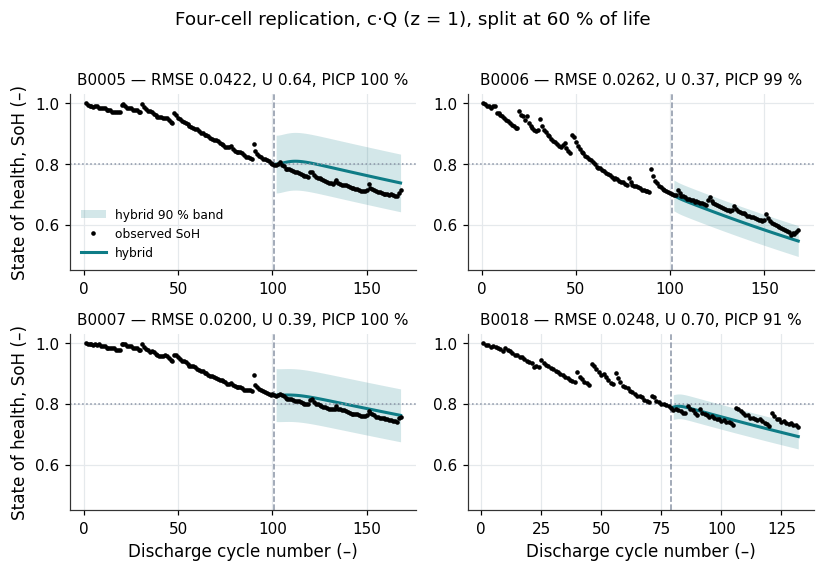

saved fig/f_otwin03_multicell.png


'fig/f_otwin03_multicell.png'

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(7.6, 5.2))
for ax, b in zip(axes.ravel(), CELLS):
    d = keep[b]; c_, s_, te = d["cyc"], d["soh"], d["te"]
    ax.fill_between(c_[te], d["hyb"]-d["q"], d["hyb"]+d["q"], color=TEAL, alpha=BAND_ALPHA, lw=0,
                    label="hybrid 90 % band")
    ax.plot(c_, s_, "o", color=OBS, ms=2.0, label="observed SoH", zorder=6)
    ax.plot(c_[te], d["hyb"], "-", color=TEAL, lw=2.0, label="hybrid")
    ax.axvline(d["split"], color="#8A94A6", ls="--", lw=1.0)
    ax.axhline(0.80, color="#8A94A6", ls=":", lw=1.0)
    ax.set_title("%s — RMSE %.4f, U %.2f, PICP %.0f %%"
                 % (b, res4[b]["RMSE"], res4[b]["TheilU"], 100*res4[b]["PICP"]), fontsize=10)
    ax.set_ylim(0.45, 1.03); despine(ax)
for ax in axes[1]: ax.set_xlabel("Discharge cycle number (–)")
for ax in axes[:, 0]: ax.set_ylabel("State of health, SoH (–)")
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Four-cell replication, c·Q (z = 1), split at 60 % of life", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.97]); save(fig, "f_otwin03_multicell")

## 7 · The interface that makes leakage impossible

`evaluate` is otwin's single entry point for scoring, and it has one rule: a forecaster
receives a **history and an integer horizon**. Not the test array. There is nothing to leak.

Wrapping the model takes fifteen lines. Then we try the classic mistake — a model whose
`predict(X)` echoes its input — and watch otwin refuse to score it.

*Look at:* the two reports lead with skill against the *hardest* baseline, and the last line is
an error, not a perfect score.

In [11]:
class FadeLawTwin:
    """Fade law + residual GP behind otwin's leakage-free forecaster interface."""
    def __init__(self, variant="b_z_1", cap1=1.0, restarts=6):
        self.variant, self.cap1, self.restarts = variant, cap1, restarts
    def forecast(self, history, horizon):
        h = np.asarray(history, float); n = len(h)
        q = np.cumsum(h*self.cap1)                       # closed-loop throughput proxy
        M = fit_all(self.variant,
                    np.arange(1.0, n+1.0+horizon),
                    np.concatenate([h, np.full(horizon, np.nan)]),
                    np.concatenate([q, np.full(horizon, np.nan)]),
                    self.cap1, float(n), n_ahead=horizon, restarts=self.restarts)
        return M["hybrid"]

tw = FadeLawTwin(variant="b_z_1", cap1=cap1)
print(evaluate(tw, soh, protocol="temporal_holdout", test_frac=0.4)); print()
print(evaluate(tw, soh, protocol="rolling_origin", n_folds=4, horizon=20))

class LeakyModel:
    def predict(self, X): return X                       # the classic: echo the test array
try:
    evaluate(LeakyModel(), soh)
except ForecastInterfaceError as e:
    print("\nForecastInterfaceError, as it should be:\n  ", str(e).split("\n")[0])

EvalReport (temporal_holdout, 1 fold)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Skill Score: -0.08 (8% WORSE than baseline)
Baseline: drift

Point Metrics:
  RMSE      0.0433 (baseline: 0.0400)
  MAE       0.0413 (baseline: 0.0324)
  NRMSE     0.3856
  MASE      8.5317
  THEIL_U   0.6398

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EvalReport (rolling_origin, 4 folds)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Skill Score: -0.50 (49% WORSE than baseline)
Baseline: persistence

Point Metrics:
  RMSE      0.0345 (baseline: 0.0231)
  MAE       0.0317 (baseline: 0.0198)
  NRMSE     0.7201
  MASE      6.9787
  THEIL_U   1.1055

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ForecastInterfaceError, as it should be:
   LeakyModel.predict returned the scalar 34.0 rather than 34 forecast steps.


## 8 · Change one thing

Learn the library by breaking the experiment. Each line below changes one choice; run it and
re-read the table.

- **A weaker reference.** Replace `theil_u(obs, pred, train)` with plain RMSE and the free-z
  model looks fine. That is what a metric without a benchmark does.
- **A different law.** Change `RECOMMENDED = "b_z_1"` to `"c_z_0p5"` in section 6. The square-root
  law is the textbook SEI law — and it loses to persistence on every cell. Physics you cannot
  identify from the data is not an advantage.
- **Less data.** In section 3 set `SPLIT = 60`. Watch the free exponent.

In [12]:
# Try it: the same free-exponent model, fitted on 60 cycles instead of 100.
SPLIT_TRY = 60
M60 = fit_all("a_free_z", cyc, soh, cum, cap1, SPLIT_TRY)
obs60, train60 = soh[cyc > SPLIT_TRY], soh[cyc <= SPLIT_TRY]
print("exponent z fitted on %d cycles: %.3f   (was %.3f on %d)" % (SPLIT_TRY, M60["p"][1], z_hat, SPLIT))
print("Theil's U vs persistence: %.3f" % theil_u(obs60, M60["hybrid"], train60))


exponent z fitted on 60 cycles: 1.411   (was 1.785 on 100)
Theil's U vs persistence: 0.304


## What you learned

- A metric without a benchmark is a number, not a score. `theil_u` and `evaluate` build the
  benchmark for you and pick the hardest one.
- A model that ties with persistence can be 70 % worse than drift. Ask for the hardest baseline.
- A parameter that moves when the split moves was chosen by the noise. Pin it, or check it.
- A band's coverage is measured, not declared — and 97 % at a 90 % target is also a finding.

**Next:** [notebook 04](otwin_04_calibrated_bands.ipynb) — building a band whose 90 % means 90 %.

---
*For CI, not for you.* The two cells below assert that this notebook still reproduces the
original study's headline numbers. If they fail, something changed in the code above.

In [13]:
# Headline numbers: computed in THIS notebook against the value recorded in the
# original notebook series (results_experiments.json).
REFERENCE = [
    ("E2 fitted exponent z (split 100)",         float(z_hat),                        1.785083670663281,   2e-2),
    ("E2 hybrid RMSE, free z, full horizon",     float(rmse(obs, M100["hybrid"])),    0.06778667689632628, 2e-2),
    ("E2 hybrid Theil's U, free z",              float(theil_u(obs, M100["hybrid"], train)), 1.0007425536365495, 2e-2),
    ("R4 mean hybrid RMSE, 4 cells (b_z_1)",     float(D4.RMSE.astype(float).mean()), 0.028314683545652496, 2e-2),
    ("R4 mean hybrid Theil's U, 4 cells",        float(D4.TheilU.astype(float).mean()), 0.5261003132061866, 2e-2),
    ("R4 mean delivered coverage, 4 cells",      float(D4.PICP.astype(float).mean()), 0.97,                3e-2),
    ("E1 B0005 cumulative throughput (Ah)",      float(f.cum_throughput_Ah.iloc[-1]), 263.62637636222814,  2e-2),
    ("E1 B0005 final SoH",                       float(f.SoH.iloc[-1]),               0.7137561578838877,  2e-2),
]
print(f"{'quantity':<52} {'this run':>14}  {'reference':>14}  {'match':>6}")
print("-"*94)
_bad = []
for name, got, ref, tol in REFERENCE:
    if isinstance(got, float) and isinstance(ref, float):
        ok = abs(got-ref) <= max(1e-12, tol*max(abs(ref), 1e-12))
        shown = f"{got:>14.6g}  {ref:>14.6g}"
    else:
        ok = (got == ref); shown = f"{str(got):>14}  {str(ref):>14}"
    print(f"{name:<52} {shown}  {'yes' if ok else 'NO':>6}")
    if not ok: _bad.append(name)
print()
print("all headline numbers reproduced through the otwin API" if not _bad else f"DRIFTED: {_bad}")


quantity                                                   this run       reference   match
----------------------------------------------------------------------------------------------
E2 fitted exponent z (split 100)                            1.78508         1.78508     yes
E2 hybrid RMSE, free z, full horizon                      0.0677867       0.0677867     yes
E2 hybrid Theil's U, free z                                 1.00074         1.00074     yes
R4 mean hybrid RMSE, 4 cells (b_z_1)                      0.0283147       0.0283147     yes
R4 mean hybrid Theil's U, 4 cells                            0.5261          0.5261     yes
R4 mean delivered coverage, 4 cells                        0.972684            0.97     yes
E1 B0005 cumulative throughput (Ah)                         263.626         263.626     yes
E1 B0005 final SoH                                         0.713756        0.713756     yes

all headline numbers reproduced through the otwin API


In [14]:
# Regression test. Fails loudly if a headline number has drifted.
assert not _bad, f"headline numbers drifted from the original notebooks: {_bad}"
print("regression test passed")


regression test passed
